In [1]:
pip install seaborn openpyxl


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
data = {
    "Platform": ["FundraiseUp", "Donorbox", "Bonterra Payments", "GiveButter", "Zeffy"],
    "Interoperability": ["🟢", "🟢", "🟢", "🟡", "🔴"],
    "Customizability": ["🟢", "🟡", "🟢", "🟢", "🔴"],
    "Data & Analytics": ["🟢", "🟡", "🟢", "🟡", "🔴"],
    "Privacy & Data Masking": ["🟢", "🟢", "🔵", "🟡", "🟡"],
    "Scalability & Traffic": ["🟢", "🟡", "🟢", "🟡", "🔴"],
    "Global Support": ["🟢", "🟢", "🟡", "🔴", "🔴"],
    "Ease of Integration": ["🟡", "🟢", "🟡", "🟢", "🟡"]
}

df = pd.DataFrame(data)

In [4]:
score_map = {"🟢": 3, "🟡": 2, "🔴": 1, "🔵": 4}

df_scores = df.copy()

for col in df.columns[1:]:
    df_scores[col] = df[col].map(score_map)

df_scores["Total Score"] = df_scores.iloc[:,1:].sum(axis=1)

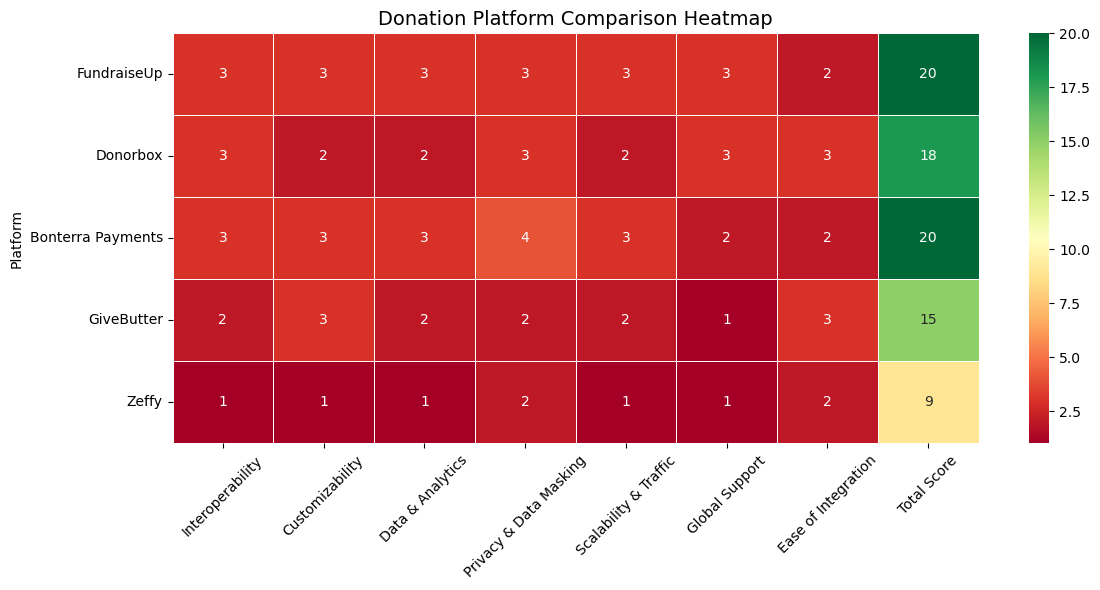

In [5]:
### beautiful headmap 
plt.figure(figsize=(12,6))

sns.heatmap(
    df_scores.set_index("Platform"),
    annot=True,
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Donation Platform Comparison Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("heatmap.png")
plt.show()

## 📊 Donation Platform Comparison Heatmap – Explanation

This heatmap provides a visual comparison of different donation platforms across key evaluation dimensions.

### What the Heatmap Represents

Each row represents a **donation platform**, and each column represents a **specific evaluation metric**, including:

- Interoperability  
- Customizability  
- Data & Analytics  
- Privacy & Data Masking  
- Scalability & Traffic  
- Global Support  
- Ease of Integration  
- Total Score  

---

### Color Interpretation

The heatmap uses a **Red–Yellow–Green color scale**:

- 🔴 **Red** → Lower scores (weaker capability)  
- 🟡 **Yellow** → Moderate performance  
- 🟢 **Green** → Higher scores (strong capability)  

This makes it easy to quickly identify strengths and weaknesses across platforms.

---

### Scoring Logic

Each metric is assigned a numerical score:

- Strong → 3  
- Moderate → 2  
- Weak → 1  
- Very Strong → 4  

The **Total Score** is calculated as the sum of all metric scores for each platform.

---

### Key Insights from the Heatmap

- **FundraiseUp** and **Bonterra Payments** show consistently high scores across most dimensions, indicating strong overall capability.
- **Donorbox** performs moderately well, especially in ease of integration and global support.
- **GiveButter** shows mixed performance, suitable for campaign-based use cases.
- **Zeffy** has lower scores across most metrics, indicating limitations in scalability and integrations.

---

### Why This Visualization is Useful

- Enables **quick comparison** across multiple platforms  
- Highlights **strengths and gaps visually**  
- Supports **data-driven decision-making**  
- Simplifies complex multi-dimensional evaluation into an intuitive format  

---

### Summary

This heatmap transforms qualitative platform evaluations into a **clear, visual, and comparative format**, helping identify the most suitable platform based on technical and operational capabilities.

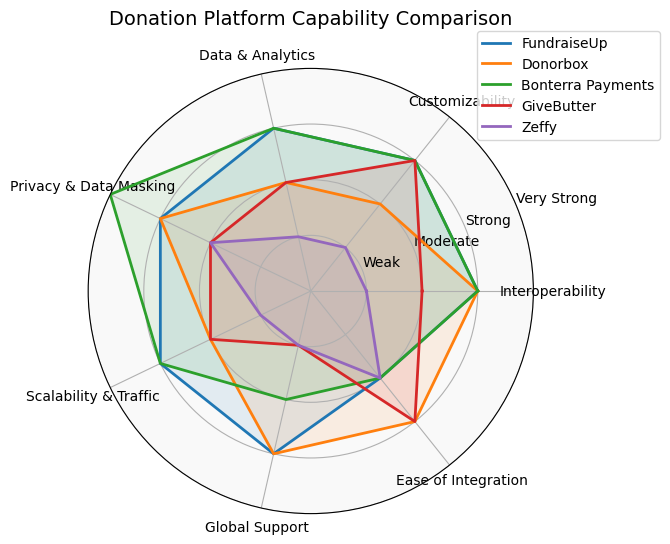

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# categories 
categories = list(df_scores.columns[1:-1])
N = len(categories)

# angles for radar
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# create plot
plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

# make grid cleaner
ax.set_facecolor("#f9f9f9")

# loop through platforms
for i, row in df_scores.iterrows():
    values = row[1:-1].tolist()
    values += values[:1]
    
    ax.plot(angles, values, linewidth=2, label=row["Platform"])
    ax.fill(angles, values, alpha=0.1)

# labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)

# set scale
ax.set_ylim(0, 4)
ax.set_yticks([1,2,3,4])
ax.set_yticklabels(["Weak","Moderate","Strong","Very Strong"])

# title
plt.title("Donation Platform Capability Comparison", size=14, y=1.08)

# legend (move outside)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig("radar_clean.png")
plt.show()

## Donation Platform Capability Comparison – Radar Chart Explanation

This radar chart provides a multi-dimensional comparison of donation platforms based on key evaluation criteria.

---

### What the Radar Chart Represents

Each axis represents a **specific capability dimension**, including:

- Interoperability  
- Customizability  
- Data & Analytics  
- Privacy & Data Masking  
- Scalability & Traffic  
- Global Support  
- Ease of Integration  

Each line represents a **donation platform**, and the shape formed shows how it performs across all dimensions.

---

### Scoring Scale

The chart uses a standardized scoring system:

- 1 → Weak  
- 2 → Moderate  
- 3 → Strong  
- 4 → Very Strong  

The farther a point is from the center, the stronger the capability.

---

### How to Interpret the Chart

- Larger, more outward shapes → stronger overall performance  
- Balanced shapes → consistent performance across dimensions  
- Irregular shapes → strengths in some areas but weaknesses in others  

---

### Key Insights

- **FundraiseUp** shows a well-balanced shape, indicating consistent strong performance across most dimensions.  
- **Bonterra Payments** extends further in areas like privacy and data handling, highlighting enterprise-level strength.  
- **Donorbox** performs moderately across most areas, with strengths in ease of integration.  
- **GiveButter** shows variability, making it more suitable for specific use cases like campaign-driven fundraising.  
- **Zeffy** remains closer to the center, indicating limited capabilities across most dimensions.

---

### Why This Visualization is Useful

- Helps identify **strength distribution** across platforms  
- Shows **balance vs specialization** in capabilities  
- Enables quick comparison of **multi-dimensional performance**  
- Supports **strategic decision-making**  

---

### Summary

The radar chart provides a holistic view of each platform’s capabilities, making it easier to understand not just how strong a platform is, but **where it is strong and where it has gaps**.

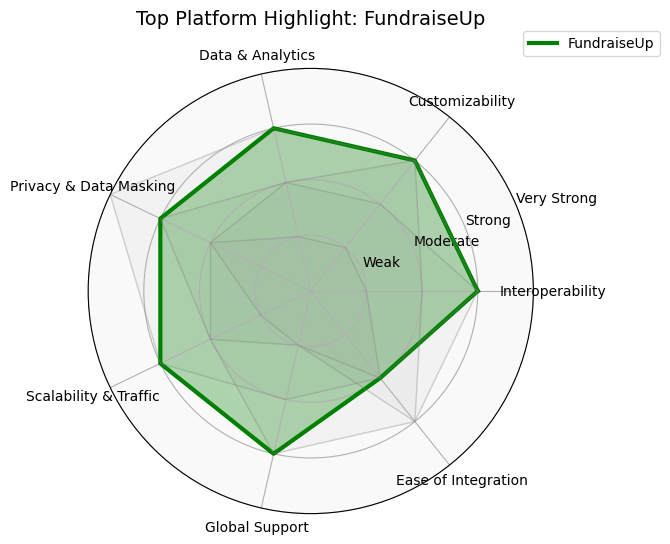

In [7]:
### highlighted radar chart showing the top platform 
import matplotlib.pyplot as plt
import numpy as np

categories = list(df_scores.columns[1:-1])
N = len(categories)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

# background
ax.set_facecolor("#f9f9f9")

for i, row in df_scores.iterrows():
    values = row[1:-1].tolist()
    values += values[:1]
    
    if row["Platform"] == "FundraiseUp":
        # ⭐ Highlight this platform
        ax.plot(angles, values, linewidth=3, color="green", label="FundraiseUp")
        ax.fill(angles, values, color="green", alpha=0.3)
    else:
        # Fade others
        ax.plot(angles, values, linewidth=1, color="gray", alpha=0.3)
        ax.fill(angles, values, color="gray", alpha=0.05)

# labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)

# scale
ax.set_ylim(0, 4)
ax.set_yticks([1,2,3,4])
ax.set_yticklabels(["Weak","Moderate","Strong","Very Strong"])

# title
plt.title("Top Platform Highlight: FundraiseUp", size=14, y=1.08)

# legend (only shows highlighted one)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig("radar_highlighted.png")
plt.show()

In [8]:
pip install dash pandas

Note: you may need to restart the kernel to use updated packages.


In [9]:
import dash
from dash import html, dcc, dash_table
from dash.dependencies import Input, Output
import pandas as pd
import plotly.express as px

# -----------------------
# DATA
# -----------------------
data = {
    "Platform": ["FundraiseUp", "Donorbox", "Bonterra Payments", "GiveButter", "Zeffy"],
    "Interoperability": [3,3,3,2,1],
    "Customizability": [3,2,3,3,1],
    "Data & Analytics": [3,2,3,2,1],
    "Privacy & Data Masking": [3,3,4,2,2],
    "Scalability & Traffic": [3,2,3,2,1],
    "Global Support": [3,3,2,1,1],
    "Ease of Integration": [2,3,2,3,2]
}

df = pd.DataFrame(data)
df["Total Score"] = df.iloc[:,1:].sum(axis=1)

# -----------------------
# APP
# -----------------------
app = dash.Dash(__name__)

app.layout = html.Div([

    html.H1("Donation Platform Interactive Dashboard",
            style={'textAlign': 'center'}),

    # DROPDOWN
    dcc.Dropdown(
        options=[{"label": p, "value": p} for p in df["Platform"]],
        value=df["Platform"].tolist(),
        multi=True,
        id="platform-filter"
    ),

    # KPI
    html.Div(id="kpi-cards", style={'display': 'flex', 'gap': '20px'}),

    # VISUALS
    dcc.Graph(id="heatmap"),
    dcc.Graph(id="bar-chart"),

    # BUTTONS
    html.Div([
        html.Button("📊 Explain Scoring", id="btn-score", n_clicks=0),
        html.Button("🏆 Highest Score Info", id="btn-max", n_clicks=0),
    ], style={'marginTop': '20px', 'display': 'flex', 'gap': '10px'}),

    # OUTPUT BOX
    html.Div(id="output-box", style={
        'marginTop': '20px',
        'padding': '20px',
        'backgroundColor': '#f4f4f4',
        'borderRadius': '10px'
    }),

], style={'padding': '30px'})


# -----------------------
# UPDATE DASHBOARD
# -----------------------
@app.callback(
    Output("heatmap", "figure"),
    Output("bar-chart", "figure"),
    Output("kpi-cards", "children"),
    Input("platform-filter", "value")
)
def update_dashboard(selected_platforms):

    if not selected_platforms:
        return {}, {}, html.Div("⚠️ Select at least one platform")

    filtered_df = df[df["Platform"].isin(selected_platforms)]

    if filtered_df.empty:
        return {}, {}, html.Div("⚠️ No data available")

    melted = filtered_df.melt(
        id_vars=["Platform"],
        var_name="Metric",
        value_name="Score"
    )

    heatmap = px.density_heatmap(
        melted,
        x="Metric",
        y="Platform",
        z="Score",
        color_continuous_scale="RdYlGn",
        title="Platform Capability Heatmap"
    )

    bar = px.bar(
        filtered_df.sort_values("Total Score", ascending=False),
        x="Platform",
        y="Total Score",
        color="Platform",
        title="Platform Ranking"
    )

    top_platform = filtered_df.loc[
        filtered_df["Total Score"].idxmax()
    ]["Platform"]

    max_score = filtered_df["Total Score"].max()

    kpis = [
        html.Div([
            html.H4("Top Platform"),
            html.H2(top_platform)
        ], style={'padding': '15px', 'background': '#e6f4ea'}),

        html.Div([
            html.H4("Highest Score"),
            html.H2(max_score)
        ], style={'padding': '15px', 'background': '#fff3cd'}),
    ]

    return heatmap, bar, kpis


# -----------------------
# BUTTON CALLBACK (UPDATED)
# -----------------------
@app.callback(
    Output("output-box", "children"),
    Input("btn-score", "n_clicks"),
    Input("btn-max", "n_clicks")
)
def explain(n1, n2):

    ctx = dash.callback_context

    if not ctx.triggered:
        return "Click a button to see explanation"

    btn = ctx.triggered[0]['prop_id'].split('.')[0]

    if btn == "btn-score":
        return html.Div([
            html.H3("📊 Scoring Methodology"),

            html.P("Each platform is evaluated across 7 key dimensions:"),

            html.Ul([
                html.Li("Interoperability (APIs, integrations)"),
                html.Li("Customizability (UI flexibility)"),
                html.Li("Data & Analytics"),
                html.Li("Privacy & Data Masking"),
                html.Li("Scalability & Traffic"),
                html.Li("Global Support"),
                html.Li("Ease of Integration")
            ]),

            html.H4("Scoring Scale"),
            html.Ul([
                html.Li("Strong = 3"),
                html.Li("Moderate = 2"),
                html.Li("Weak = 1"),
                html.Li("Very Strong = 4")
            ]),

            html.H4("Total Score Formula"),
            html.P("Total Score = Sum of all dimension scores"),

            html.H4("Example"),
            html.P("FundraiseUp: 3+3+3+3+3+3+2 = 20"),

            html.H4("Maximum Possible Score"),
            html.P("≈ 21–22 depending on 'Very Strong' values"),

            html.P("This scoring enables structured comparison and visualization across platforms.")
        ])

    elif btn == "btn-max":
        return html.Div([
            html.H3("🏆 Highest Score Insight"),
            html.P("Top platforms: FundraiseUp and Bonterra Payments"),
            html.P("They achieve high scores due to strong performance across most dimensions."),
            html.P("They are best suited for scalable and enterprise-grade use cases.")
        ])


# -----------------------
# RUN
# -----------------------
if __name__ == '__main__':
    app.run(debug=True, use_reloader=False)

In [10]:
df.to_excel("donation_platform_dashboard.xlsx", index=False)